# init

## setup environments

In [3]:
import pandas as pd
from matplotlib import pyplot as plt
import networkx as nx
import numpy as np

# load dataset

In [4]:
# X_train, y_train, X_test = crunch.load_data()
X_train = pd.read_pickle("data/X_train.pickle")
y_train = pd.read_pickle("data/y_train.pickle")
X_test = pd.read_pickle("data/X_test_reduced.pickle")

## utilities

In [5]:
def graph_nodes_representation(graph, nodelist):
    adjacency_matrix = nx.adjacency_matrix(graph, nodelist=nodelist).todense()
    return tuple(adjacency_matrix.flatten())

def create_graph_label():
    graph_label = {
        nx.DiGraph([("X", "Y"), ("v", "X"), ("v", "Y")]): "Confounder",
        nx.DiGraph([("X", "Y"), ("X", "v"), ("Y", "v")]): "Collider",
        nx.DiGraph([("X", "Y"), ("X", "v"), ("v", "Y")]): "Mediator",
        nx.DiGraph([("X", "Y"), ("v", "X")]): "Cause of X",
        nx.DiGraph([("X", "Y"), ("v", "Y")]): "Cause of Y",
        nx.DiGraph([("X", "Y"), ("X", "v")]): "Consequence of X",
        nx.DiGraph([("X", "Y"), ("Y", "v")]): "Consequence of Y",
        nx.DiGraph({"X": ["Y"], "v": []}): "Independent",
    }
    nodelist = ["v", "X", "Y"]
    adjacency_label = {
        graph_nodes_representation(graph, nodelist): label
        for graph, label in graph_label.items()
    }
    return graph_label, adjacency_label

_GRAPH_LABEL, _ADJACENCY_LABEL = None, None

def get_adjacency_label():
    global _GRAPH_LABEL, _ADJACENCY_LABEL
    if _ADJACENCY_LABEL is None:
        _GRAPH_LABEL, _ADJACENCY_LABEL = create_graph_label()
    return _ADJACENCY_LABEL

def get_labels(adjacency_matrix, adjacency_label):
    result = {}
    for variable in adjacency_matrix.columns.drop(["X", "Y"]):
        submatrix = adjacency_matrix.loc[
            [variable, "X", "Y"], [variable, "X", "Y"]
        ]
        key = tuple(submatrix.values.flatten())
        result[variable] = adjacency_label[key]
    return result

def transform_proba_to_DAG(nodes, pred):
    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    G.add_edge("X", "Y")
    x_index, y_index = np.unravel_index(
        np.argsort(pred.ravel())[::-1], pred.shape
    )
    for i, j in zip(x_index, y_index):
        n1, n2 = nodes[i], nodes[j]
        if i == j:
            continue
        if {n1, n2} == {"X", "Y"}:
            continue
        if pred[i, j] > 0.5:
            G.add_edge(n1, n2)
            if not nx.is_directed_acyclic_graph(G):
                G.remove_edge(n1, n2)
    return nx.to_numpy_array(G)

def _edge_type(u_name, v_name):
    """Edge type encoding (7 types) as described in the report."""
    uX, uY = u_name == "X", u_name == "Y"
    vX, vY = v_name == "X", v_name == "Y"
    if uX and not vY:  return 0   # u=X, v≠Y
    if uX and vY:      return 1   # u=X, v=Y
    if uY and not vX:  return 2   # u=Y, v≠X
    if uY and vX:      return 3   # u=Y, v=X
    if not uX and not uY and vX: return 4  # u∉{X,Y}, v=X
    if not uX and not uY and vY: return 5  # u∉{X,Y}, v=Y
    return 6                                # none of the above

# eda

## init

In [6]:
train_names: list[str] = list(X_train.keys())
sample_train_name: str = train_names[2]
sample_train_name

'00007'

In [7]:
# ── Edge type classifier (1-7) ────────────────────────────────────────────────
def edge_type(u, v):
    if u == 'X' and v != 'Y': return 1, 'X→u'
    if u == 'X' and v == 'Y': return 2, 'X→Y'
    if u == 'Y' and v != 'X': return 3, 'Y→u'
    if u == 'Y' and v == 'X': return 4, 'Y→X'
    if u not in ('X','Y') and v == 'X': return 5, 'u→X'
    if u not in ('X','Y') and v == 'Y': return 6, 'u→Y'
    return 7, 'u→v'

# ── Node role classifier ──────────────────────────────────────────────────────
def node_role(k):
    if k in ('X', 'Y'):
        return k  # keep X and Y labelled as-is
    kx = G.has_edge(k, 'X')
    ky = G.has_edge(k, 'Y')
    xk = G.has_edge('X', k)
    yk = G.has_edge('Y', k)
    # priority order matters for nodes that could match multiple patterns
    if kx and ky:           return 'Confounder'
    if xk and yk:           return 'Collider'
    if xk and ky:           return 'Mediator'
    if yk:                  return 'Conseq. of Y'
    if xk:                  return 'Conseq. of X'
    if kx:                  return 'Cause of X'
    if ky:                  return 'Cause of Y'
    return 'Independent'


## graph stats

            n_edges       density      in_deg_Y      in_deg_X  n_confounders  \
count  23500.000000  23500.000000  23500.000000  23500.000000   23500.000000   
mean      11.205362      0.222484      2.775021      0.908809       0.384809   
std        4.167770      0.099576      1.303763      1.062768       0.694711   
min        2.000000      0.077778      1.000000      0.000000       0.000000   
25%        9.000000      0.144444      2.000000      0.000000       0.000000   
50%       11.000000      0.194444      3.000000      1.000000       0.000000   
75%       14.000000      0.266667      4.000000      1.000000       1.000000   
max       34.000000      0.500000      9.000000      8.000000       8.000000   

        n_mediators   n_colliders  
count  23500.000000  23500.000000  
mean       0.259404      0.231660  
std        0.532475      0.515674  
min        0.000000      0.000000  
25%        0.000000      0.000000  
50%        0.000000      0.000000  
75%        0.000000      0.

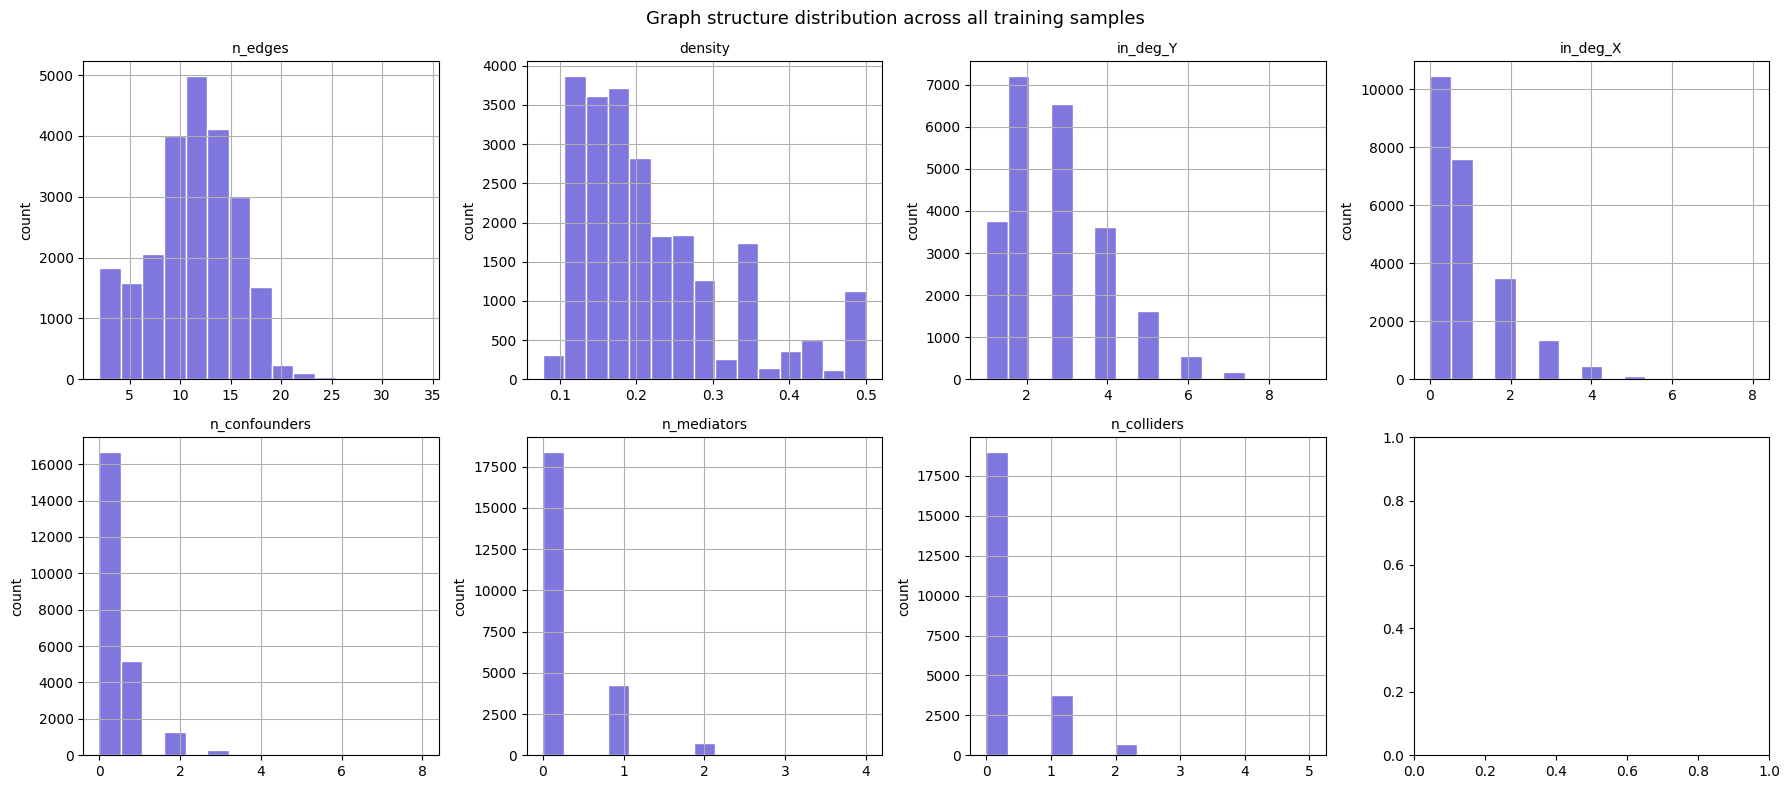

In [8]:
stats = []
for name in train_names:
    adj = y_train[name]
    G = nx.DiGraph()
    for p in adj.index:
        for c in adj.columns:
            if adj.loc[p, c] == 1:
                G.add_edge(p, c)
    roles = {n: node_role(n) for n in G.nodes}  # reuse your classifier
    stats.append({
        'name':        name,
        'n_edges':     G.number_of_edges(),
        'density':     nx.density(G),
        'xy_path':     nx.has_path(G, 'X', 'Y'),
        'in_deg_Y':    G.in_degree('Y'),
        'in_deg_X':    G.in_degree('X'),
        'n_confounders': sum(1 for r in roles.values() if r == 'Confounder'),
        'n_mediators':   sum(1 for r in roles.values() if r == 'Mediator'),
        'n_colliders':   sum(1 for r in roles.values() if r == 'Collider'),
    })

df_stats = pd.DataFrame(stats)
print(df_stats.describe())
print(f"X⇢Y some path:  {df_stats['xy_path'].mean():.1%} of samples")

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, ['n_edges','density','in_deg_Y','in_deg_X',
                                'n_confounders','n_mediators','n_colliders']):
    df_stats[col].hist(ax=ax, bins=15, color='#7F77DD', edgecolor='white')
    ax.set_title(col, fontsize=10); ax.set_xlabel(''); ax.set_ylabel('count')
plt.suptitle('Graph structure distribution across all training samples', fontsize=13)
plt.tight_layout(); plt.show()

## correlation

In [9]:
sample_df: pd.DataFrame = X_train[sample_train_name]
sample_df

,0,1,2,3,4,5,Y,7,8,X
0,-0.789,-0.357,0.071,0.509,-0.603,-0.861,0.617,0.559,0.999,0.671
1,0.851,0.539,0.491,0.827,0.049,0.013,-0.007,-0.667,-0.127,-0.673
2,-0.777,-0.869,-0.965,-0.877,0.025,0.837,0.657,-0.069,-0.927,-0.477
3,-0.955,0.381,-0.293,0.239,-0.629,-0.511,0.065,-0.479,0.157,0.523
4,-0.881,0.337,-0.653,-0.203,-0.521,-0.493,0.193,-0.439,-0.469,0.729
...,...,...,...,...,...,...,...,...,...,...
995,-0.035,-0.873,0.637,0.493,0.887,0.375,0.687,-0.661,0.127,-0.729
996,-0.229,0.467,-0.435,-0.399,0.839,0.795,0.075,-0.927,-0.465,-0.593
997,0.149,-0.037,0.985,0.515,0.491,0.427,0.549,-0.361,0.061,-0.769
998,0.175,-0.085,0.563,0.377,-0.601,-0.417,-0.257,0.765,0.241,0.251


In [10]:
adj_df: pd.DataFrame = y_train[sample_train_name]
adj_df

,0,1,2,3,4,5,Y,7,8,X
parent,,,,,,,,,,
0,0,0,1,0,0,0,1,0,0,0
1,0,0,0,0,0,0,1,0,0,0
2,0,0,0,0,0,0,0,0,1,0
3,0,0,1,0,0,1,1,0,0,0
4,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,1,0,0,0,1,0
Y,0,0,0,0,0,0,0,1,0,0
7,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,1,0,0,0,0,0


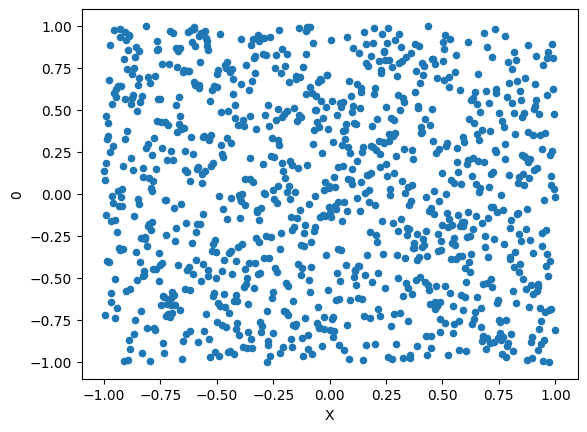

In [11]:
def plot_scatter(df: pd.DataFrame, x_col: str, y_col: str):
    sorted_df: pd.DataFrame = df[[x_col, y_col]].sort_values(x_col)

    sorted_df.plot(x = x_col, y = y_col, kind = 'scatter')

plot_scatter(sample_df, 'X', '0')

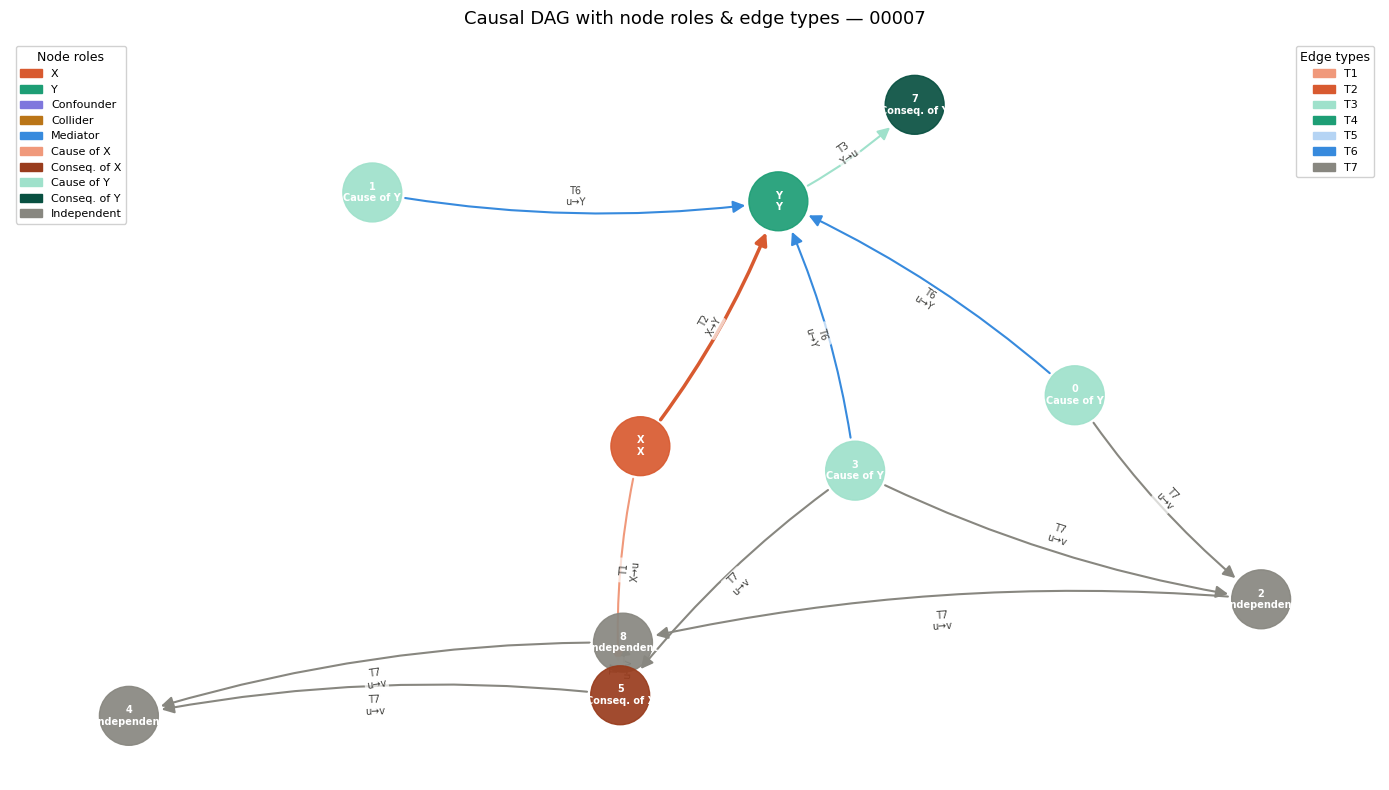

In [12]:
# ── Build graph ───────────────────────────────────────────────────────────────
from mpmath import mp
from matplotlib import patches as mpatches
G = nx.DiGraph()
for parent in adj_df.index:
    for child in adj_df.columns:
        if adj_df.loc[parent, child] == 1:
            G.add_edge(parent, child)

# ── Edge type classifier (1-7) ────────────────────────────────────────────────
def edge_type(u, v):
    if u == 'X' and v != 'Y': return 1, 'X→u'
    if u == 'X' and v == 'Y': return 2, 'X→Y'
    if u == 'Y' and v != 'X': return 3, 'Y→u'
    if u == 'Y' and v == 'X': return 4, 'Y→X'
    if u not in ('X','Y') and v == 'X': return 5, 'u→X'
    if u not in ('X','Y') and v == 'Y': return 6, 'u→Y'
    return 7, 'u→v'

# ── Node role classifier ──────────────────────────────────────────────────────
def node_role(k):
    if k in ('X', 'Y'):
        return k  # keep X and Y labelled as-is
    kx = G.has_edge(k, 'X')
    ky = G.has_edge(k, 'Y')
    xk = G.has_edge('X', k)
    yk = G.has_edge('Y', k)
    # priority order matters for nodes that could match multiple patterns
    if kx and ky:           return 'Confounder'
    if xk and yk:           return 'Collider'
    if xk and ky:           return 'Mediator'
    if yk:                  return 'Conseq. of Y'
    if xk:                  return 'Conseq. of X'
    if kx:                  return 'Cause of X'
    if ky:                  return 'Cause of Y'
    return 'Independent'

# ── Assign roles and edge labels ──────────────────────────────────────────────
roles       = {n: node_role(n) for n in G.nodes}
edge_labels = {(u, v): f"T{edge_type(u,v)[0]}\n{edge_type(u,v)[1]}" for u,v in G.edges}

# ── Color maps ────────────────────────────────────────────────────────────────
role_colors = {
    'X':             '#D85A30',   # coral  — treatment
    'Y':             '#1D9E75',   # teal   — outcome
    'Confounder':    '#7F77DD',   # purple
    'Collider':      '#BA7517',   # amber
    'Mediator':      '#378ADD',   # blue
    'Cause of X':    '#F0997B',   # light coral
    'Conseq. of X':  '#993C1D',   # dark coral
    'Cause of Y':    '#9FE1CB',   # light teal
    'Conseq. of Y':  '#085041',   # dark teal
    'Independent':   '#888780',   # gray
}

edge_type_colors = {1:'#F0997B', 2:'#D85A30', 3:'#9FE1CB', 4:'#1D9E75', 5:'#B5D4F4', 6:'#378ADD', 7:'#888780'}
edge_colors = [edge_type_colors[edge_type(u,v)[0]] for u,v in G.edges]
edge_widths = [2.5 if edge_type(u,v)[0] in (2,) else 1.5 for u,v in G.edges]  # highlight X→Y

# ── Node display labels: "id\nRole" ───────────────────────────────────────────
node_labels = {n: f"{n}\n{roles[n]}" for n in G.nodes}
node_colors = [role_colors.get(roles[n], '#888780') for n in G.nodes]

# ── Layout and draw ───────────────────────────────────────────────────────────
try:
    pos = nx.nx_agraph.graphviz_layout(G, prog='dot')
except Exception:
    pos = nx.spring_layout(G, seed=42)

fig, ax = plt.subplots(figsize=(14, 8))

nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=1800, alpha=0.92)
nx.draw_networkx_labels(G, pos, ax=ax, labels=node_labels,
                        font_size=7, font_color='white', font_weight='bold')
nx.draw_networkx_edges(G, pos, ax=ax, edge_color=edge_colors, width=edge_widths,
                       arrows=True, arrowsize=18, node_size=1800, min_source_margin=24, min_target_margin=24,
                       connectionstyle='arc3,rad=0.08')  # slight curve avoids overlap
nx.draw_networkx_edge_labels(G, pos, ax=ax, edge_labels=edge_labels,
                              font_size=7, font_color='#3d3d3a',
                              bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none'))

# ── Legends ───────────────────────────────────────────────────────────────────
node_legend = [mpatches.Patch(color=c, label=r) for r, c in role_colors.items()]
edge_legend = [mpatches.Patch(color=c, label=f"T{t}") for t, c in edge_type_colors.items()]

leg1 = ax.legend(handles=node_legend, title='Node roles',
                 loc='upper left', fontsize=8, title_fontsize=9, framealpha=0.9)
ax.legend(handles=edge_legend, title='Edge types',
          loc='upper right', fontsize=8, title_fontsize=9, framealpha=0.9)
ax.add_artist(leg1)

ax.set_title(f'Causal DAG with node roles & edge types — {sample_train_name}', fontsize=13, pad=12)
ax.axis('off')
plt.tight_layout()
plt.show()

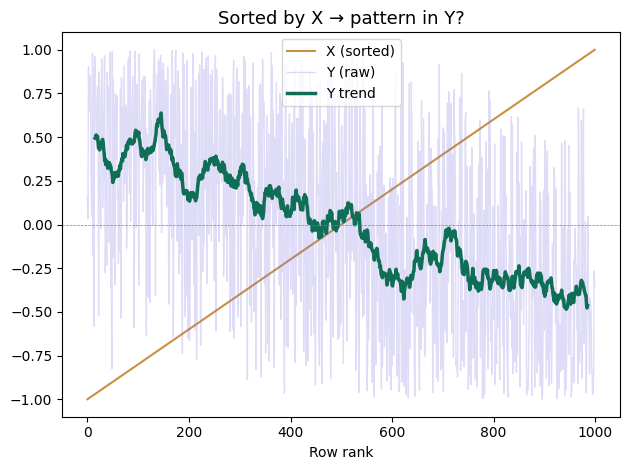

In [19]:
# --- 2. Sorted variable plot ---
sort_var, compare_var = 'X', 'Y'
df_sorted = sample_df.sort_values(by=sort_var).reset_index(drop=True)

plt.plot(df_sorted[sort_var].values, alpha=0.8, label=f'{sort_var} (sorted)', lw=1.5, color='#BA7517')
plt.plot(df_sorted[compare_var].values, alpha=0.25, label=f'{compare_var} (raw)', lw=1, color='#7F77DD')
plt.plot(df_sorted[compare_var].rolling(30, center=True).mean().values,
             label=f'{compare_var} trend', lw=2.5, color='#0F6E56')
plt.axhline(0, color='gray', lw=0.5, ls='--')
plt.title(f'Sorted by {sort_var} → pattern in {compare_var}?', fontsize=13)
plt.legend(fontsize=10)
plt.xlabel('Row rank')
plt.tight_layout()
plt.show()

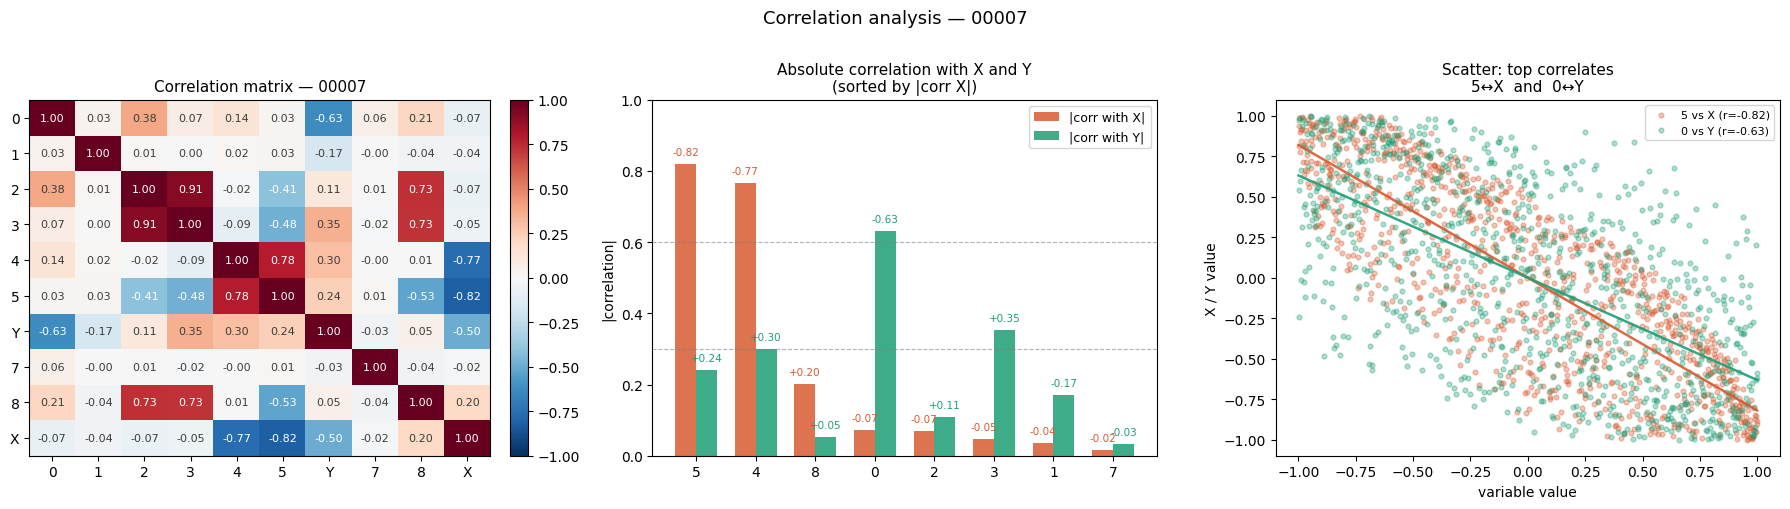

In [14]:
# ── Correlation section ───────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1. Full correlation heatmap ───────────────────────────────────────────────
corr = sample_df.corr()
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
im = axes[0].imshow(corr.values, cmap='RdBu_r', norm=norm, aspect='auto')
axes[0].set_xticks(range(len(corr.columns))); axes[0].set_xticklabels(corr.columns)
axes[0].set_yticks(range(len(corr.index)));   axes[0].set_yticklabels(corr.index)
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        v = corr.iloc[i, j]
        axes[0].text(j, i, f'{v:.2f}', ha='center', va='center',
                     fontsize=8, color='white' if abs(v) > 0.4 else '#3d3d3a')
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
axes[0].set_title(f'Correlation matrix — {sample_train_name}', fontsize=11)

# ── 2. Correlation sorted by |corr with X| and |corr with Y| ─────────────────
corr_xy = corr[['X', 'Y']].drop(index=['X', 'Y']).abs().sort_values('X', ascending=False)
x_pos = np.arange(len(corr_xy))
w = 0.35
axes[1].bar(x_pos - w/2, corr_xy['X'], width=w, color='#D85A30', alpha=0.85, label='|corr with X|')
axes[1].bar(x_pos + w/2, corr_xy['Y'], width=w, color='#1D9E75', alpha=0.85, label='|corr with Y|')
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(corr_xy.index)
axes[1].set_ylabel('|correlation|'); axes[1].set_ylim(0, 1)
axes[1].axhline(0.3, color='gray', lw=0.8, ls='--', alpha=0.6)   # weak threshold
axes[1].axhline(0.6, color='gray', lw=0.8, ls='--', alpha=0.6)   # moderate threshold
axes[1].legend(fontsize=9)
axes[1].set_title('Absolute correlation with X and Y\n(sorted by |corr X|)', fontsize=11)

# annotate each bar with the signed correlation value (not just absolute)
for i, node in enumerate(corr_xy.index):
    for offset, col_key, color in [(-w/2, 'X', '#D85A30'), (w/2, 'Y', '#1D9E75')]:
        signed = corr.loc[node, col_key]
        axes[1].text(i + offset, corr_xy.loc[node, col_key] + 0.02,
                     f'{signed:+.2f}', ha='center', va='bottom', fontsize=7.5, color=color)

# ── 3. Scatter: pair most correlated with X vs most correlated with Y ─────────
# also overlay X and Y themselves for context
top_x = corr_xy['X'].idxmax()
top_y = corr_xy['Y'].idxmax()

sc = axes[2].scatter(sample_df[top_x], sample_df['X'], alpha=0.35, s=12,
                     color='#D85A30', label=f'{top_x} vs X (r={corr.loc[top_x,"X"]:.2f})')
sc2 = axes[2].scatter(sample_df[top_y], sample_df['Y'], alpha=0.35, s=12,
                      color='#1D9E75', label=f'{top_y} vs Y (r={corr.loc[top_y,"Y"]:.2f})')

# regression lines
for xs_key, ys_key, c in [(top_x, 'X', '#D85A30'), (top_y, 'Y', '#1D9E75')]:
    xs, ys = sample_df[xs_key].values, sample_df[ys_key].values
    m, b = np.polyfit(xs, ys, 1)
    xr = np.linspace(xs.min(), xs.max(), 100)
    axes[2].plot(xr, m*xr + b, color=c, lw=1.8, alpha=0.9)

axes[2].set_xlabel('variable value'); axes[2].set_ylabel('X / Y value')
axes[2].legend(fontsize=8)
axes[2].set_title(f'Scatter: top correlates\n{top_x}↔X  and  {top_y}↔Y', fontsize=11)

plt.suptitle(f'Correlation analysis — {sample_train_name}', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## conditional independence tests

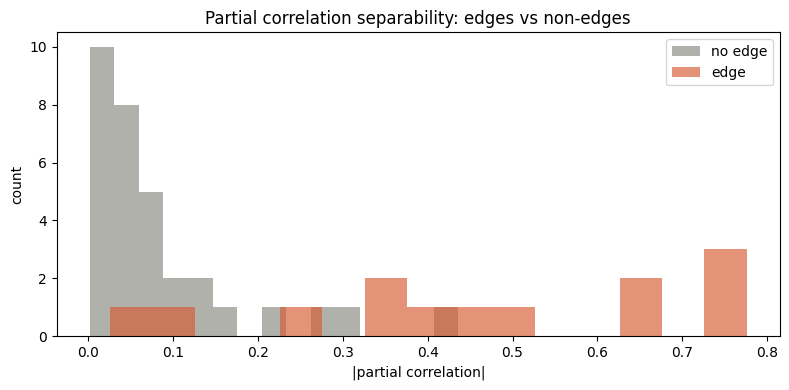

pair  r_raw  r_partial  p_partial  edge_exists
 2—3  0.914      0.776     0.0000            1
 5—X -0.820     -0.775     0.0000            1
 0—Y -0.632     -0.745     0.0000            1
 4—8  0.005      0.655     0.0000            1
 4—5  0.783      0.643     0.0000            1
 3—5 -0.481     -0.497     0.0000            1
 0—2  0.385      0.453     0.0000            1
 3—X -0.047     -0.436     0.0000            0
 1—Y -0.171     -0.417     0.0000            1
 5—8 -0.526     -0.348     0.0000            1
 Y—X -0.499     -0.332     0.0000            1
 0—X -0.071     -0.301     0.0000            0
 0—1  0.035     -0.284     0.0000            0
 3—Y  0.353      0.268     0.0000            1
 0—3  0.071     -0.215     0.0000            0
 4—X -0.766      0.165     0.0000            0
 1—X -0.036     -0.142     0.0000            0
 1—3  0.004      0.134     0.0000            0
 3—4 -0.091      0.099     0.0019            0
 0—8  0.209      0.098     0.0020            0
 2—8  0.732  

In [15]:
from itertools import combinations
import pingouin as pg  # pip install pingouin

sample_df = X_train[sample_train_name]

results = []
cols = list(sample_df.columns)
for x, y in combinations(cols, 2):
    covariates = [c for c in cols if c not in (x, y)]
    # unconditional
    r_raw = sample_df[[x, y]].corr().iloc[0, 1]
    # conditioned on all others (full partial)
    pc = pg.partial_corr(data=sample_df, x=x, y=y, covar=covariates)
    results.append({
        'pair': f'{x}—{y}',
        'r_raw':     round(r_raw, 3),
        'r_partial': round(pc['r'].values[0], 3),
        'p_partial': round(pc['p_val'].values[0], 4),
        'edge_exists': int(y_train[sample_train_name].loc[x, y] == 1
                           or y_train[sample_train_name].loc[y, x] == 1)
    })

df_pc = pd.DataFrame(results).sort_values('r_partial', key=abs, ascending=False)

# How well does |partial corr| separate edges from non-edges?
fig, ax = plt.subplots(figsize=(8, 4))
for label, grp in df_pc.groupby('edge_exists'):
    ax.hist(grp['r_partial'].abs(), bins=15, alpha=0.65,
            label=f"{'edge' if label else 'no edge'}",
            color='#D85A30' if label else '#888780')
ax.set_xlabel('|partial correlation|')
ax.set_ylabel('count')
ax.legend()
ax.set_title('Partial correlation separability: edges vs non-edges')
plt.tight_layout(); plt.show()

print(df_pc.to_string(index=False))

## non-gaussianity tests

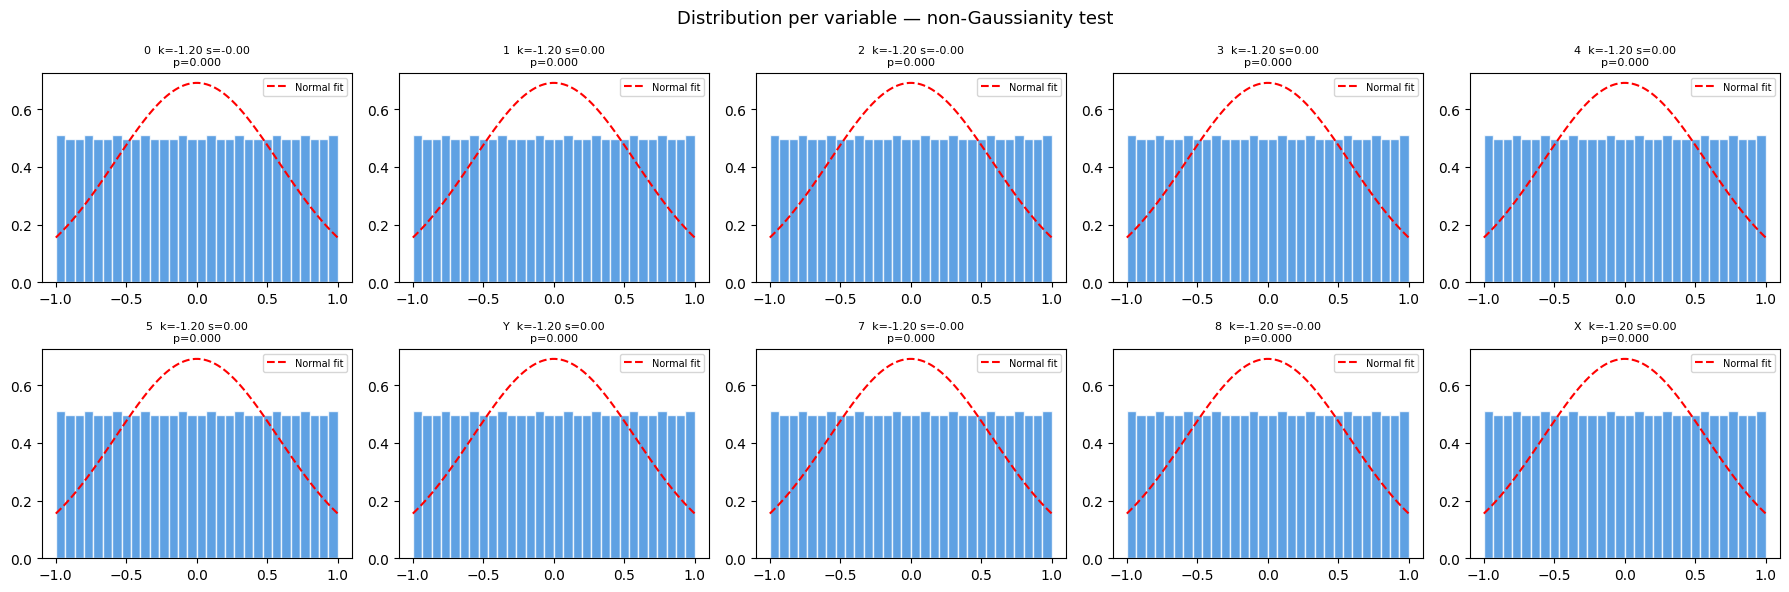

   kurtosis  skew  normal_p
3      -1.2   0.0       0.0
5      -1.2   0.0       0.0
X      -1.2   0.0       0.0
Y      -1.2   0.0       0.0
0      -1.2  -0.0       0.0
2      -1.2  -0.0       0.0
4      -1.2   0.0       0.0
1      -1.2   0.0       0.0
7      -1.2  -0.0       0.0
8      -1.2  -0.0       0.0


In [16]:
from scipy import stats as spstats

fig, axes = plt.subplots(2, 5, figsize=(18, 6))
normality = {}
for ax, col in zip(axes.flat, sample_df.columns):
    ax.hist(sample_df[col], bins=30, color='#378ADD', edgecolor='white', alpha=0.8, density=True)
    xs = np.linspace(sample_df[col].min(), sample_df[col].max(), 100)
    ax.plot(xs, spstats.norm.pdf(xs, sample_df[col].mean(), sample_df[col].std()),
            'r--', lw=1.5, label='Normal fit')
    stat, p = spstats.normaltest(sample_df[col])   # D'Agostino-Pearson
    kurt = spstats.kurtosis(sample_df[col])
    skew = spstats.skew(sample_df[col])
    ax.set_title(f'{col}  k={kurt:.2f} s={skew:.2f}\np={p:.3f}', fontsize=8)
    normality[col] = {'kurtosis': kurt, 'skew': skew, 'normal_p': p}
    ax.legend(fontsize=7)

plt.suptitle('Distribution per variable — non-Gaussianity test', fontsize=13)
plt.tight_layout(); plt.show()

df_norm = pd.DataFrame(normality).T.sort_values('normal_p')
print(df_norm.round(3))

## additive noise tests

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from scipy.stats import spearmanr

def anm_score(x, y, degree=3):
    """Lower score = residuals more independent of input = x→y more plausible."""
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(x.reshape(-1,1), y)
    residuals = y - model.predict(x.reshape(-1,1))
    corr, _ = spearmanr(x, residuals)   # should be ~0 if x→y
    return abs(corr)

pairs_of_interest = [('X','Y'), ('X','5'), ('5','Y'), ('3','Y'), ('0','Y')]
print(f"{'pair':<10} {'score x→y':>12} {'score y→x':>12} {'preferred':>12} {'true edge':>12}")
print('-'*55)
for u, v in pairs_of_interest:
    xu, xv = sample_df[u].values, sample_df[v].values
    s_fwd = anm_score(xu, xv)
    s_bwd = anm_score(xv, xu)
    preferred = f'{u}→{v}' if s_fwd < s_bwd else f'{v}→{u}'
    true_edge = y_train[sample_train_name].loc[u, v]
    print(f"{u}→{v:<6} {s_fwd:>12.4f} {s_bwd:>12.4f} {preferred:>12} {true_edge:>12}")

pair          score x→y    score y→x    preferred    true edge
-------------------------------------------------------
X→Y            0.0270       0.0293          X→Y            1
X→5            0.0367       0.0179          5→X            1
5→Y            0.0078       0.0116          5→Y            0
3→Y            0.0126       0.0182          3→Y            1
0→Y            0.0347       0.0310          Y→0            1


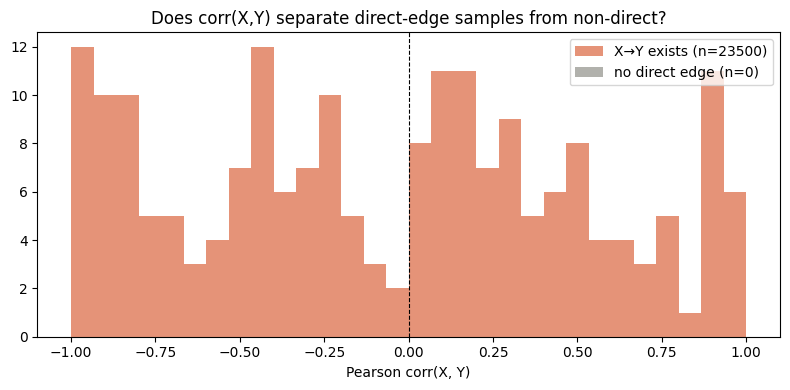

In [18]:
direct_xy = [n for n in train_names if y_train[n].loc['X','Y'] == 1]
no_xy     = [n for n in train_names if y_train[n].loc['X','Y'] == 0]

corrs_direct = [X_train[n][['X','Y']].corr().iloc[0,1] for n in direct_xy[:200]]
corrs_none   = [X_train[n][['X','Y']].corr().iloc[0,1] for n in no_xy[:200]]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(corrs_direct, bins=30, alpha=0.65, color='#D85A30', label=f'X→Y exists (n={len(direct_xy)})')
ax.hist(corrs_none,   bins=30, alpha=0.65, color='#888780', label=f'no direct edge (n={len(no_xy)})')
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('Pearson corr(X, Y)')
ax.legend()
ax.set_title('Does corr(X,Y) separate direct-edge samples from non-direct?')
plt.tight_layout(); plt.show()